## Reproduce results from “Modeling BBR’s Interactions with Loss-Based Congestion Control”

This notebook will reproduce selected findings from

> Ranysha Ware, Matthew K. Mukerjee, Srinivasan Seshan, and Justine Sherry. 2019. Modeling BBR’s Interactions with Loss-Based Congestion Control. In Proceedings of the Internet Measurement Conference (IMC ’19). Association for Computing Machinery, New York, NY, USA, 137–143. https://doi.org/10.1145/3355369.3355604

specifically,

-   Figure 1b and 1c (initial measurements of BBR’s empirical behaviors)
-   Figure 2: BBR vs Cubic in a 40ms × 10Mbps network (convergence time and goodput for 1 BBR and 1 Cubic flow over varying queue sizes)
-   Figure 3: BBR and Cubic or Reno’s queue when competing for 4 minutes over a network with a 64 BDP (1024 packet) queue

The following group of cells installs prerequisites for data analysis and visualization:

In [1]:
!pip install seaborn

In [2]:
import time
import pandas as pd
from io import StringIO
import seaborn as sns 
import matplotlib.pyplot as plt

### Configure environment

In [3]:
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
fablib = fablib_manager() 
conf = fablib.show_config()

Credential Manager,cm.fabric-testbed.net
Orchestrator,orchestrator.fabric-testbed.net
Project ID,073ee843-2310-45bd-a01f-a15d808827dc
Token File,/home/fabric/.tokens.json
Bastion Host,bastion.fabric-testbed.net
Bastion Username,fbs6417_0000066146
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Private Key File,/home/fabric/work/fabric_config/slice_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Log File,/tmp/fablib/fablib.log
Log Level,INFO


### Define configuration for this experiment

In [4]:
slice_name="ware" + fablib.get_bastion_username()

node_conf = [
 {'name': "sender",    'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']}, 
 {'name': "receiver",  'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']}, 
 {'name': "router",    'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['iperf3', 'net-tools', 'moreutils','python3']}
]
net_conf = [
 {"name": "net0", "subnet": "10.0.0.0/24", "nodes": [{"name": "sender",   "addr": "10.0.0.100"}, {"name": "router", "addr": "10.0.0.1"}]},
 {"name": "net1", "subnet": "10.0.1.0/24", "nodes": [{"name": "receiver", "addr": "10.0.1.100"}, {"name": "router", "addr": "10.0.1.1"}]},
]
route_conf = [
 {"addr": "10.0.1.0/24", "gw": "10.0.0.1", "nodes": ["sender"]}, 
 {"addr": "10.0.0.0/24", "gw": "10.0.1.1", "nodes": ["receiver"]}
]
exp_conf = {'cores': sum([ n['cores'] for n in node_conf]), 'nic': sum([len(n['nodes']) for n in net_conf]) }

### Reserve resources

Now, we are ready to reserve resources!

First, make sure you don’t already have a slice with this name:

In [5]:
try:
    slice = fablib.get_slice(slice_name)
    print("You already have a slice by this name!")
    print("If you previously reserved resources, skip to the 'log in to resources' section.")
except:
    print("You don't have a slice named %s yet." % slice_name)
    print("Continue to the next step to make one.")
    slice = fablib.new_slice(name=slice_name)

You already have a slice by this name!
If you previously reserved resources, skip to the 'log in to resources' section.


We will select a random site that has sufficient resources for our experiment:

In [6]:
while True:
    site_name = fablib.get_random_site()
    if ( (fablib.resources.get_core_available(site_name) > 1.2*exp_conf['cores']) and
        (fablib.resources.get_component_available(site_name, 'SharedNIC-ConnectX-6') > 1.2**exp_conf['nic']) ):
        break

fablib.show_site(site_name)

Name,HAWI
State,Active
Address,"2520 Correa Road,Honolulu, Hi 96822"
Location,"(21.2989762, -157.8163991)"
PTP Capable,True
Hosts,5
CPUs,10
Cores Available,316
Cores Capacity,640
Cores Allocated,324
Ram Available,886


'<pandas.io.formats.style.Styler object at 0x7a0ea0676e50>'

Then we will add hosts and network segments:

In [7]:
# this cell sets up the nodes
for n in node_conf:
    slice.add_node(name=n['name'], site=site_name, 
                   cores=n['cores'], 
                   ram=n['ram'], 
                   disk=n['disk'], 
                   image=n['image'])

In [8]:
# this cell sets up the network segments
for n in net_conf:
    ifaces = [slice.get_node(node["name"]).add_component(model="NIC_Basic", 
                                                 name=n["name"]).get_interfaces()[0] for node in n['nodes'] ]
    slice.add_l2network(name=n["name"], type='L2Bridge', interfaces=ifaces)

The following cell submits our request to the FABRIC site. The output of this cell will update automatically as the status of our request changes.

-   While it is being prepared, the “State” of the slice will appear as “Configuring”.
-   When it is ready, the “State” of the slice will change to “StableOK”.

You may prefer to walk away and come back in a few minutes (for simple slices) or a few tens of minutes (for more complicated slices with many resources).

In [9]:
slice.submit()


Retry: 7, Time: 219 sec


ID,026589d4-8cdf-42f5-a23a-5fc970d7c061
Name,ware-figure8a-bbr3-1fbs6417_0000066146
Lease Expiration (UTC),2025-02-28 17:51:48 +0000
Lease Start (UTC),2025-02-27 17:51:48 +0000
Project ID,073ee843-2310-45bd-a01f-a15d808827dc
State,StableOK


ID,Name,Cores,RAM,Disk,Image,Image Type,Host,Site,Username,Management IP,State,Error,SSH Command,Public SSH Key File,Private SSH Key File
31a1e5ae-609a-47f5-b2bd-72c77ba8c5cf,receiver,2,4,10,default_ubuntu_22,qcow2,hawi-w4.fabric-testbed.net,HAWI,ubuntu,2607:f278:1:202:f816:3eff:fe3e:dafd,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fe3e:dafd,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
7c382243-dc02-4397-b759-05e49382f6c8,router,2,4,10,default_ubuntu_22,qcow2,hawi-w4.fabric-testbed.net,HAWI,ubuntu,2607:f278:1:202:f816:3eff:fef3:b3c,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fef3:b3c,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
a9048da3-0df3-4368-a102-6ce9ded9ef04,sender,2,4,10,default_ubuntu_22,qcow2,hawi-w4.fabric-testbed.net,HAWI,ubuntu,2607:f278:1:202:f816:3eff:fe17:f3d5,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fe17:f3d5,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key


ID,Name,Layer,Type,Site,Subnet,Gateway,State,Error
798cf7ca-88ef-4870-9948-1b515d525856,net0,L2,L2Bridge,HAWI,None,None,Active,
95880675-5452-44c6-9afb-5ff2b53389b2,net1,L2,L2Bridge,HAWI,None,None,Active,


Name,Short Name,Node,Network,Bandwidth,Mode,VLAN,MAC,Physical Device,Device,IP Address,Numa Node,Switch Port
sender-net0-p1,p1,sender,net0,100,config,,0A:19:C5:E3:2A:F6,enp7s0,enp7s0,fe80::819:c5ff:fee3:2af6,4,HundredGigE0/0/0/11
receiver-net1-p1,p1,receiver,net1,100,config,,0A:5D:FA:82:7E:00,enp7s0,enp7s0,fe80::85d:faff:fe82:7e00,4,HundredGigE0/0/0/11
router-net0-p1,p1,router,net0,100,config,,0A:B4:27:E5:4A:99,enp7s0,enp7s0,fe80::8b4:27ff:fee5:4a99,4,HundredGigE0/0/0/11
router-net1-p1,p1,router,net1,100,config,,0A:FC:63:63:64:6B,enp8s0,enp8s0,fe80::8fc:63ff:fe63:646b,4,HundredGigE0/0/0/11



Time to print interfaces 235 seconds


'026589d4-8cdf-42f5-a23a-5fc970d7c061'

In [10]:
slice.get_state()
slice.wait_ssh(progress=True)

Waiting for slice . Slice state: StableOK
Waiting for ssh in slice . ssh successful


True

### Extend your slice

If you don’t plan to finish an experiment in one day, you can extend your slice. The following cell extends your reservation for 7 days.

In [11]:
from datetime import datetime
from datetime import timezone
from datetime import timedelta

# Set end date to 7 days from now
end_date = (datetime.now(timezone.utc) + timedelta(days=7)).strftime("%Y-%m-%d %H:%M:%S %z")
slice.renew(end_date)

### Install BBR2 Kernel

In [ ]:
pkg_list = ['linux-headers-5.13.12_5.13.12-2_amd64.deb',
            'linux-libc-dev_5.13.12-2_amd64.deb',
            'linux-image-5.13.12_5.13.12-2_amd64.deb']

cmd_BBRv2 = """sudo grub-set-default "Advanced options for Ubuntu>Ubuntu, with Linux 5.13.12"
sudo grub-mkconfig -o /boot/grub/grub.cfg
sudo sed -i 's/^GRUB_DEFAULT=.*/GRUB_DEFAULT=saved/' /etc/default/grub
sudo update-grub 
sudo reboot"""


for pkg in pkg_list:
        slice.get_node(name="sender").execute("wget https://raw.githubusercontent.com/sdatta97/imcbbrrepro/main/setup/{packet}".format(packet=pkg))
        slice.get_node(name="receiver").execute("wget https://raw.githubusercontent.com/sdatta97/imcbbrrepro/main/setup/{packet}".format(packet=pkg))

slice.get_node(name="sender").execute("sudo dpkg -i  *.deb")
slice.get_node(name="sender").execute(cmd_BBRv2)

slice.get_node(name="receiver").execute("sudo dpkg -i  *.deb")
slice.get_node(name="receiver").execute(cmd_BBRv2)

### Install BBR3 Kernel

In [11]:
pkg_list = ['linux-headers-6.4.0+_6.4.0-g6e321d1c986a-5_amd64.deb',
            'linux-image-6.4.0+_6.4.0-g6e321d1c986a-5_amd64.deb',
            'linux-libc-dev_6.4.0-g6e321d1c986a-5_amd64.deb']

cmd_BBRv3 ="""sudo grub-set-default "Advanced options for Ubuntu>Ubuntu, with Linux 6.4.0"
sudo grub-mkconfig -o /boot/grub/grub.cfg
sudo sed -i 's/^GRUB_DEFAULT=.*/GRUB_DEFAULT=saved/' /etc/default/grub
sudo update-grub
sudo reboot"""

for pkg in pkg_list:
    slice.get_node(name="sender").execute("wget https://github.com/ashutoshs25/bbrv3-kernel/raw/main/{packet}".format(packet=pkg))
    slice.get_node(name="receiver").execute("wget https://github.com/ashutoshs25/bbrv3-kernel/raw/main/{packet}".format(packet=pkg))
    
slice.get_node(name="sender").execute("sudo dpkg -i  *.deb")
slice.get_node(name="sender").execute(cmd_BBRv3)

slice.get_node(name="receiver").execute("sudo dpkg -i  *.deb")
slice.get_node(name="receiver").execute(cmd_BBRv3)

 --2025-02-27 18:03:39--  https://github.com/ashutoshs25/bbrv3-kernel/raw/main/linux-headers-6.4.0+_6.4.0-g6e321d1c986a-5_amd64.deb
Resolving github.com (github.com)... 2600:2701:5000:5001::8c52:7103, 140.82.113.3
Connecting to github.com (github.com)|2600:2701:5000:5001::8c52:7103|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ashutoshs25/bbrv3-kernel/main/linux-headers-6.4.0%2B_6.4.0-g6e321d1c986a-5_amd64.deb [following]
--2025-02-27 18:03:40--  https://raw.githubusercontent.com/ashutoshs25/bbrv3-kernel/main/linux-headers-6.4.0%2B_6.4.0-g6e321d1c986a-5_amd64.deb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8000::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9640406 (9.2M) [application/octet-stream]
Saving to: ‘linux-headers

('',
 "Sourcing file `/etc/default/grub'\nSourcing file `/etc/default/grub.d/50-cloudimg-settings.cfg'\nSourcing file `/etc/default/grub.d/init-select.cfg'\nGenerating grub configuration file ...\nFound linux image: /boot/vmlinuz-6.4.0+\nFound initrd image: /boot/initrd.img-6.4.0+\nFound linux image: /boot/vmlinuz-5.15.0-127-generic\nFound initrd image: /boot/initrd.img-5.15.0-127-generic\nWarning: os-prober will not be executed to detect other bootable partitions.\nSystems on them will not be added to the GRUB boot configuration.\nCheck GRUB_DISABLE_OS_PROBER documentation entry.\ndone\nSourcing file `/etc/default/grub'\nSourcing file `/etc/default/grub.d/50-cloudimg-settings.cfg'\nSourcing file `/etc/default/grub.d/init-select.cfg'\nGenerating grub configuration file ...\nFound linux image: /boot/vmlinuz-6.4.0+\nFound initrd image: /boot/initrd.img-6.4.0+\nFound linux image: /boot/vmlinuz-5.15.0-127-generic\nFound initrd image: /boot/initrd.img-5.15.0-127-generic\nWarning: os-prober 

### Configure resources

Next, we will configure the resources so they are ready to use.

In [12]:
slice = fablib.get_slice(name=slice_name)

In [13]:
# install packages
# this will take a while and will run in background while you do other steps
for n in node_conf:
    if len(n['packages']):
        node = slice.get_node(n['name'])
        pkg = " ".join(n['packages'])
        node.execute_thread("sudo apt update; sudo DEBIAN_FRONTEND=noninteractive apt -y install %s" % pkg)

In [14]:
# bring interfaces up and either assign an address (if there is one) or flush address
from ipaddress import ip_address, IPv4Address, IPv4Network

for net in net_conf:
    for n in net['nodes']:
        if_name = n['name'] + '-' + net['name'] + '-p1'
        iface = slice.get_interface(if_name)
        iface.ip_link_up()
        if n['addr']:
            iface.ip_addr_add(addr=n['addr'], subnet=IPv4Network(net['subnet']))
        else:
            iface.get_node().execute("sudo ip addr flush dev %s"  % iface.get_device_name())

In [15]:
# make sure all interfaces are brought up
for iface in slice.get_interfaces():
    iface.ip_link_up()

In [16]:
# prepare a "hosts" file that has names and addresses of every node
hosts_txt = [ "%s\t%s" % ( n['addr'], n['name'] ) for net in net_conf  for n in net['nodes'] if type(n) is dict and n['addr']]
for n in slice.get_nodes():
    for h in hosts_txt:
        n.execute("echo %s | sudo tee -a /etc/hosts" % h)

10.0.0.100 sender
10.0.0.1 router
10.0.1.100 receiver
10.0.1.1 router
10.0.0.100 sender
10.0.0.1 router
10.0.1.100 receiver
10.0.1.1 router
10.0.0.100 sender
10.0.0.1 router
10.0.1.100 receiver
10.0.1.1 router


In [17]:
# enable IPv4 forwarding on all nodes
for n in slice.get_nodes():
    n.execute("sudo sysctl -w net.ipv4.ip_forward=1")

net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1


In [18]:
# set up static routes
for rt in route_conf:
    for n in rt['nodes']:
        slice.get_node(name=n).ip_route_add(subnet=IPv4Network(rt['addr']), gateway=rt['gw'])

In [19]:
# turn off segmentation offload on interfaces
for iface in slice.get_interfaces():
    iface_name = iface.get_device_name()
    n = iface.get_node()
    offloads = ["gro", "lro", "gso", "tso"]
    for offload in offloads:
        n.execute("sudo ethtool -K %s %s off" % (iface_name, offload))

### Validate base network

Before we run any experiment, we should check the “base” network - before adding any emulated delay or rate limiting - and make sure that it will not be a limiting factor in the experiment.

In [20]:
# check base delay
_ = slice.get_node("sender").execute("ping -c 5 receiver")

PING receiver (10.0.1.100) 56(84) bytes of data.
64 bytes from receiver (10.0.1.100): icmp_seq=1 ttl=63 time=3.41 ms
64 bytes from receiver (10.0.1.100): icmp_seq=2 ttl=63 time=0.171 ms
64 bytes from receiver (10.0.1.100): icmp_seq=3 ttl=63 time=0.191 ms
64 bytes from receiver (10.0.1.100): icmp_seq=4 ttl=63 time=0.164 ms
64 bytes from receiver (10.0.1.100): icmp_seq=5 ttl=63 time=0.184 ms

--- receiver ping statistics ---
5 packets transmitted, 5 received, 0% packet loss, time 4078ms
rtt min/avg/max/mdev = 0.164/0.823/3.408/1.292 ms


In [21]:
# check base capacity (by sending 10 parallel flows, look at their sum throughput)
import time
_ = slice.get_node("receiver").execute("iperf3 -s -1 -D")
time.sleep(5)
_ = slice.get_node("sender").execute("iperf3 -t 30 -i 10 -P 10 -c receiver")

Connecting to host receiver, port 5201
[  5] local 10.0.0.100 port 44634 connected to 10.0.1.100 port 5201
[  7] local 10.0.0.100 port 44648 connected to 10.0.1.100 port 5201
[  9] local 10.0.0.100 port 44664 connected to 10.0.1.100 port 5201
[ 11] local 10.0.0.100 port 44678 connected to 10.0.1.100 port 5201
[ 13] local 10.0.0.100 port 44680 connected to 10.0.1.100 port 5201
[ 15] local 10.0.0.100 port 44682 connected to 10.0.1.100 port 5201
[ 17] local 10.0.0.100 port 44694 connected to 10.0.1.100 port 5201
[ 19] local 10.0.0.100 port 44698 connected to 10.0.1.100 port 5201
[ 21] local 10.0.0.100 port 44706 connected to 10.0.1.100 port 5201
[ 23] local 10.0.0.100 port 44712 connected to 10.0.1.100 port 5201
[ ID] Interval           Transfer     Bitrate         Retr  Cwnd
[  5]   0.00-10.00  sec  1.13 GBytes   973 Mbits/sec  998    441 KBytes       
[  7]   0.00-10.00  sec   609 MBytes   511 Mbits/sec  506    246 KBytes       
[  9]   0.00-10.00  sec  1.59 GBytes  1.37 Gbits/sec  329 

In [22]:
# also check Linux kernel version on sender
_ = slice.get_node("sender").execute("uname -a")

Linux sender 6.4.0+ #5 SMP PREEMPT_DYNAMIC Thu Nov  9 17:46:47 UTC 2023 x86_64 x86_64 x86_64 GNU/Linux


### Draw the network topology

The following cell will draw the network topology, for your reference. The interface name and addresses of each experiment interface will be shown on the drawing.

In [23]:
l2_nets = [(n.get_name(), {'color': 'lavender'}) for n in slice.get_l2networks() ]
l3_nets = [(n.get_name(), {'color': 'pink'}) for n in slice.get_l3networks() ]
hosts   =   [(n.get_name(), {'color': 'lightblue'}) for n in slice.get_nodes()]
nodes = l2_nets + l3_nets + hosts
ifaces = [iface.toDict() for iface in slice.get_interfaces()]
edges = [(iface['network'], iface['node'], 
          {'label': iface['physical_dev'] + '\n' + iface['ip_addr'] + '\n' + iface['mac']}) for iface in ifaces]

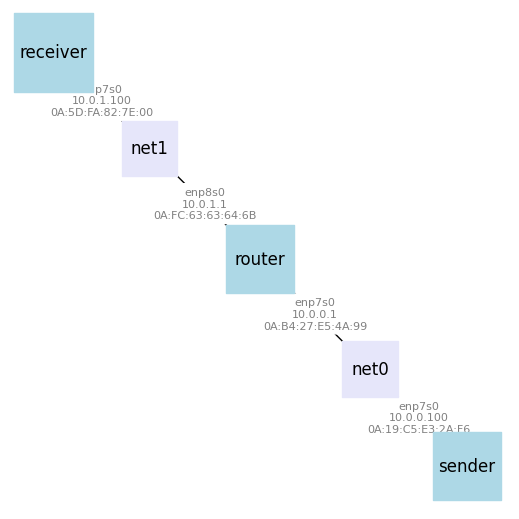

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
plt.figure(figsize=(len(nodes),len(nodes)))
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw(G, pos, node_shape='s',  
        node_color=[n[1]['color'] for n in nodes], 
        node_size=[len(n[0])*400 for n in nodes],  
        with_labels=True);
nx.draw_networkx_edge_labels(G,pos,
                             edge_labels=nx.get_edge_attributes(G,'label'),
                             font_color='gray',  font_size=8, rotate=False);

### Log into resources

Now, we are finally ready to log in to our resources over SSH! Run the following cells, and observe the table output - you will see an SSH command for each of the resources in your topology.

In [25]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
slice_info = [{'Name': n.get_name(), 'SSH command': n.get_ssh_command()} for n in slice.get_nodes()]
pd.DataFrame(slice_info).set_index('Name')

,SSH command
Name,
sender,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fe17:f3d5
receiver,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fe3e:dafd
router,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2607:f278:1:202:f816:3eff:fef3:b3c


Now, you can open an SSH session on any of the resources as follows:

-   in Jupyter, from the menu bar, use File \> New \> Terminal to open a new terminal.
-   copy an SSH command from the table, and paste it into the terminal. (Note that each SSH command is a single line, even if the display wraps the text to a second line! When you copy and paste it, paste it all together.)

You can repeat this process (open several terminals) to start a session on each resource. Each terminal session will have a tab in the Jupyter environment, so that you can easily switch between them.

### Configure the network capacity and delay

In this section, we configure the bottleneck link to have a 40Mbps capacity and 10ms delay. We will initialize the queue size to 32 BDP (although we will change this later).

In [26]:
exp = {'rtt': 40, 'bandwidth': 10 }
bdp_kbyte = exp['rtt']*exp['bandwidth']/8

router_node = slice.get_node("router")
router_ingress_iface = router_node.get_interface(network_name = "net0")
router_ingress_name = router_ingress_iface.get_device_name()
router_egress_iface  = router_node.get_interface(network_name = "net1")
router_egress_name = router_egress_iface.get_device_name()

router_node.execute("sudo tc qdisc del dev " + router_ingress_name + " root")
router_node.execute("sudo tc qdisc del dev " + router_egress_name + " root")

# set up RTT
router_node.execute("sudo tc qdisc replace dev " + router_ingress_name + " root netem delay " + str(exp['rtt']) + "ms limit 10000")
# set up rate limit, buffer limit
router_node.execute("sudo tc qdisc replace dev " + router_egress_name + " root handle 1: htb default 3")
router_node.execute("sudo tc class add dev " + router_egress_name + " parent 1: classid 1:3 htb rate " + str(exp['bandwidth']) + "Mbit")
router_node.execute("sudo tc qdisc add dev " + router_egress_name + " parent 1:3 bfifo limit " + str(bdp_kbyte*32) + "kb")


 Error: Cannot delete qdisc with handle of zero.
  Error: Cannot delete qdisc with handle of zero.
 

('', '')

Then, we validate the new network setting.

In [27]:
# check base delay
_ = slice.get_node("sender").execute("ping -c 5 receiver")

PING receiver (10.0.1.100) 56(84) bytes of data.
64 bytes from receiver (10.0.1.100): icmp_seq=1 ttl=63 time=40.4 ms
64 bytes from receiver (10.0.1.100): icmp_seq=2 ttl=63 time=40.2 ms
64 bytes from receiver (10.0.1.100): icmp_seq=3 ttl=63 time=40.3 ms
64 bytes from receiver (10.0.1.100): icmp_seq=4 ttl=63 time=40.3 ms
64 bytes from receiver (10.0.1.100): icmp_seq=5 ttl=63 time=40.2 ms

--- receiver ping statistics ---
5 packets transmitted, 5 received, 0% packet loss, time 4006ms
rtt min/avg/max/mdev = 40.237/40.282/40.409/0.064 ms


In [28]:
# check base capacity (by sending 10 parallel flows, look at their sum throughput)
import time
_ = slice.get_node("receiver").execute("iperf3 -s -1 -D")
time.sleep(5)
_ = slice.get_node("sender").execute("iperf3 -t 30 -i 10 -P 10 -c receiver")

Connecting to host receiver, port 5201
[  5] local 10.0.0.100 port 47578 connected to 10.0.1.100 port 5201
[  7] local 10.0.0.100 port 47590 connected to 10.0.1.100 port 5201
[  9] local 10.0.0.100 port 47606 connected to 10.0.1.100 port 5201
[ 11] local 10.0.0.100 port 47608 connected to 10.0.1.100 port 5201
[ 13] local 10.0.0.100 port 47620 connected to 10.0.1.100 port 5201
[ 15] local 10.0.0.100 port 47626 connected to 10.0.1.100 port 5201
[ 17] local 10.0.0.100 port 47632 connected to 10.0.1.100 port 5201
[ 19] local 10.0.0.100 port 47640 connected to 10.0.1.100 port 5201
[ 21] local 10.0.0.100 port 47652 connected to 10.0.1.100 port 5201
[ 23] local 10.0.0.100 port 47658 connected to 10.0.1.100 port 5201
[ ID] Interval           Transfer     Bitrate         Retr  Cwnd
[  5]   0.00-10.00  sec  2.01 MBytes  1.69 Mbits/sec   59    182 KBytes       
[  7]   0.00-10.00  sec  2.07 MBytes  1.74 Mbits/sec   60    181 KBytes       
[  9]   0.00-10.00  sec  2.07 MBytes  1.74 Mbits/sec   53 

### Reproduce Figure 8 

In [6]:
router_node = slice.get_node("router")
sender_node = slice.get_node("sender")
receiver_node = slice.get_node("receiver")

In [7]:
router_ingress_iface = router_node.get_interface(network_name = "net0")
router_ingress_name = router_ingress_iface.get_device_name()
router_egress_iface  = router_node.get_interface(network_name = "net1")
router_egress_name = router_egress_iface.get_device_name()

In [8]:
sender_node.execute("uname -r")
receiver_node.execute("uname -r")

6.4.0+
6.4.0+


('6.4.0+\n', '')

In [9]:
import itertools

# Base factors that remain constant across specific combinations
exp_factors = {
    'bufcap': [2**n for n in range(7)],
    'duration': [1000],
    'bbr_flow_number':[2**(n) for n in range(6)],
    'trial': [1,2,3]
}

# List the specific combinations you need
specific_combinations = [
    {'rtt': 40, 'bandwidth': 10, 'loss_cc': 'cubic'},
#    {'rtt': 40, 'bandwidth': 10, 'loss_cc': 'reno'},
#    {'rtt': 30, 'bandwidth': 50, 'loss_cc': 'cubic'}
]

# Generate all possible combinations of the base factors
base_combinations = list(itertools.product(*[[(k, v) for v in values] for k, values in exp_factors.items()]))

# Convert list of tuples to list of dictionaries
base_combinations = [dict(items) for items in base_combinations]

# Expand the specific combinations with the base combinations
exp_lists = [
    {**base, **specific}
    for base in base_combinations
    for specific in specific_combinations
]
print(len(exp_lists))

12


In [10]:
#We increase the socket buffer sizes to prevent becoming application-limited or receiver window-limited when we use large buffers.

sender_node.execute("sudo sysctl -w net.core.rmem_max=67108864")
sender_node.execute("sudo sysctl -w net.core.wmem_max=67108864")

sender_node.execute("sudo sysctl -w net.ipv4.tcp_wmem='4096 262144 67108864'")
sender_node.execute("sudo sysctl -w net.ipv4.tcp_rmem='4096 524288 67108864'")

sender_node.execute("echo 'net.ipv4.tcp_wmem = 4096 262144 67108864' | sudo tee -a /etc/sysctl.conf")
sender_node.execute("echo 'net.ipv4.tcp_rmem = 4096 524288 67108864' | sudo tee -a /etc/sysctl.conf")
sender_node.execute("sudo sysctl -p")

net.core.rmem_max = 67108864
net.core.wmem_max = 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864


('net.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\nnet.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\nnet.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\n',
 '')

In [11]:
#We increase the socket buffer sizes to prevent becoming application-limited or receiver window-limited when we use large buffers.

receiver_node.execute("sudo sysctl -w net.core.rmem_max=67108864")
receiver_node.execute("sudo sysctl -w net.core.wmem_max=67108864")

receiver_node.execute("sudo sysctl -w net.ipv4.tcp_wmem='4096 262144 67108864'")
receiver_node.execute("sudo sysctl -w net.ipv4.tcp_rmem='4096 524288 67108864'")

receiver_node.execute("echo 'net.ipv4.tcp_wmem = 4096 262144 67108864' | sudo tee -a /etc/sysctl.conf")
receiver_node.execute("echo 'net.ipv4.tcp_rmem = 4096 524288 67108864' | sudo tee -a /etc/sysctl.conf")
receiver_node.execute("sudo sysctl -p")

net.core.rmem_max = 67108864
net.core.wmem_max = 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864
net.ipv4.tcp_wmem = 4096 262144 67108864
net.ipv4.tcp_rmem = 4096 524288 67108864


('net.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\nnet.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\nnet.ipv4.tcp_wmem = 4096 262144 67108864\nnet.ipv4.tcp_rmem = 4096 524288 67108864\n',
 '')

In [12]:
# check the buffer sizes

sender_node.execute("sysctl net.ipv4.tcp_wmem net.ipv4.tcp_rmem net.core.wmem_max net.core.rmem_max")
receiver_node.execute("sysctl net.ipv4.tcp_wmem net.ipv4.tcp_rmem net.core.wmem_max net.core.rmem_max")

net.ipv4.tcp_wmem = 4096	262144	67108864
net.ipv4.tcp_rmem = 4096	524288	67108864
net.core.wmem_max = 67108864
net.core.rmem_max = 67108864
net.ipv4.tcp_wmem = 4096	262144	67108864
net.ipv4.tcp_rmem = 4096	524288	67108864
net.core.wmem_max = 67108864
net.core.rmem_max = 67108864


('net.ipv4.tcp_wmem = 4096\t262144\t67108864\nnet.ipv4.tcp_rmem = 4096\t524288\t67108864\nnet.core.wmem_max = 67108864\nnet.core.rmem_max = 67108864\n',
 '')

In [ ]:
import time


# make sure that you are using correct kernel. 

# We used: 
    # BBRv2 kernel for BBRv1 or BBRv2
    # BBRv3 kernel for BBRv3 


# make sure BBR is available # this is BBRv3 in BBRv3 kernel, otherwise it is BBRv1. 
# In BBRv3 kernel, BBRv1 is bbr1 not bbr.


sender_node.execute("sudo modprobe tcp_bbr") 
receiver_node.execute("sudo modprobe tcp_bbr")

# if you use BBRv2 kernel, you can do this.

#sender_node.execute("sudo modprobe tcp_bbr2")
#receiver_node.execute("sudo modprobe tcp_bbr2")

for exp in exp_lists:

# You will see fig8a_bbr3 in below. you may need to adjust these parameter names. This is for the network setting in Figure 8a in Ware paper and we run BBRv3 flows against single loss-based flow CUBIC or RENO.
    
    name_tx_BBR="fig8a_bbr3_" + str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])+ ".txt"
    name_tx_loss="fig8a_" + exp['loss_cc'] + "_" + str(exp['bufcap']) +"_"+str(exp['bandwidth'])+"_"+str(exp['rtt'])+"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])+ ".txt"

    file_out_tx_BBR_json = name_tx_BBR
    stdout_tx_BBR_json, stderr_tx_BBR_json = receiver_node.execute("ls " + file_out_tx_BBR_json, quiet=True) 
    
    file_out_tx_loss_json =name_tx_loss
    stdout_tx_loss_json, stderr_tx_loss_json = receiver_node.execute("ls " + file_out_tx_loss_json, quiet=True) 
    

    if len(stdout_tx_BBR_json) and len(stdout_tx_loss_json):
        print("Already have " + name_tx_BBR + " and "+ name_tx_loss + ", skipping")

    elif len(stderr_tx_BBR_json) or len(stderr_tx_loss_json):
        #print("Running experiment to generate " + name_tx_BBR + " and "+ name_tx_loss) 

        print("Running:",exp)
        sender_node.execute("sudo modprobe tcp_bbr")
        #sender_node.execute("sudo modprobe tcp_bbr2")

        
        router_node.execute("sudo tc qdisc del dev " + router_ingress_name + " root")
        router_node.execute("sudo tc qdisc del dev " + router_egress_name + " root")
        router_node.execute("sudo tc qdisc replace dev " + router_ingress_name + " root netem delay " + str(exp['rtt']) + "ms limit 10000")
        router_node.execute("sudo tc qdisc replace dev " + router_egress_name + " root handle 1: htb default 3")
        router_node.execute("sudo tc class replace dev " + router_egress_name + " parent 1: classid 1:3 htb rate " + str(exp['bandwidth']) + "Mbit")
        
        # set router buffer limit 
        bdp_kbyte = exp['rtt']*exp['bandwidth']/8
        router_node.execute("sudo tc qdisc replace dev " + router_egress_name + " parent 1:3 bfifo limit " + str(bdp_kbyte*exp['bufcap']) + "kb")
        
        # clean up
        receiver_node.execute("sudo killall iperf3")
        sender_node.execute("sudo killall iperf3")
        
        time.sleep(5) 
        
        # start an iperf3 receiver for the BBR flow
        receiver_node.execute_thread("iperf3 -s -1 -i 1 -fm --logfile fig8a_bbr3_" + str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])+ ".txt")
        
        # start an iperf3 receiver for the loss based CC flows (Cubic & Reno)
        receiver_node.execute_thread("iperf3 -s -1 -i 1 -fm --logfile fig8a_" + exp['loss_cc'] + "_" + str(exp['bufcap']) +"_"+str(exp['bandwidth'])+"_"+str(exp['rtt'])+"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])+ ".txt -p 5301")
    
        time.sleep(10) 
    
        ss_tx_script="rm -f {flow}-ss.txt; start_time=$(date +%s); while true; do ss --no-header -eipn dst 10.0.1.100:5201 | ts '%.s' | tee -a {flow}-ss.txt; current_time=$(date +%s); elapsed_time=$((current_time - start_time));  if [ $elapsed_time -ge {duration} ]; then break; fi; sleep 0.1; done;"
        ss_tx_script_v2="rm -f {flow}-ss.txt; start_time=$(date +%s); while true; do ss --no-header -eipn dst 10.0.1.100:5301 | ts '%.s' | tee -a {flow}-ss.txt; current_time=$(date +%s); elapsed_time=$((current_time - start_time));  if [ $elapsed_time -ge {duration} ]; then break; fi; sleep 0.1; done;"
    
        router_script="sleep 4; rm {flow}-queue.txt; start_time=$(date +%s); while true; do tc -p -s -d qdisc show dev {iface} | tr -d \'\n\' | ts '%.s' | tee -a {flow}-queue.txt; echo \"\" | tee -a {flow}-queue.txt; current_time=$(date +%s); elapsed_time=$((current_time - start_time));  if [ $elapsed_time -ge {duration} ]; then break; fi; sleep 0.01; done;"
    
        router_node.execute_thread(router_script.format(flow=str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number']), iface=router_egress_name, duration=exp["duration"]))
    
        sender_node.execute_thread(ss_tx_script.format(flow=str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number']), duration=exp['duration']))
        sender_node.execute_thread(ss_tx_script_v2.format(flow="cubic-"+str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number']), duration=exp['duration']))
    
        # IMPORTANT: YOU NEED TO ADJUST WHAT TYPE OF BBR FLOW YOU ARE SENDING. HERE, BBR IS USED FOR BBRV3 IN BBRV3 KERNEL. YOU MAY NEED TO CHANGE THIS.
        
        # start an iperf3 sender for the BBR flow
        sender_node.execute_thread("sleep 1; iperf3 -c receiver -fm -t " + str(exp['duration']) + " -C bbr -P "+str(exp['bbr_flow_number']))
        # start an iperf3 sender for the loss based CC flows (Cubic & Reno)
        sender_node.execute_thread("sleep 1; iperf3 -c receiver -fm -t " + str(exp['duration']) + " -C " + exp['loss_cc'] + " -p 5301")
    
        time.sleep(exp['duration'] + 10)
    
print("done")

Already have fig8a_bbr3_32_10_40_1_bbr3Vcubic_1.txt and fig8a_cubic_32_10_40_1_bbr3Vcubic_1.txt, skipping
Already have fig8a_bbr3_32_10_40_1_bbr3Vcubic_2.txt and fig8a_cubic_32_10_40_1_bbr3Vcubic_2.txt, skipping
Already have fig8a_bbr3_32_10_40_1_bbr3Vcubic_4.txt and fig8a_cubic_32_10_40_1_bbr3Vcubic_4.txt, skipping
Already have fig8a_bbr3_32_10_40_1_bbr3Vcubic_8.txt and fig8a_cubic_32_10_40_1_bbr3Vcubic_8.txt, skipping
Already have fig8a_bbr3_32_10_40_1_bbr3Vcubic_16.txt and fig8a_cubic_32_10_40_1_bbr3Vcubic_16.txt, skipping
Running: {'bufcap': 32, 'duration': 1000, 'bbr_flow_number': 32, 'trial': 1, 'rtt': 40, 'bandwidth': 10, 'loss_cc': 'cubic'}
 iperf3: no process found
  iperf3: no process found
 Running: {'bufcap': 64, 'duration': 1000, 'bbr_flow_number': 1, 'trial': 1, 'rtt': 40, 'bandwidth': 10, 'loss_cc': 'cubic'}
 iperf3: no process found
  iperf3: no process found
 Running: {'bufcap': 64, 'duration': 1000, 'bbr_flow_number': 2, 'trial': 1, 'rtt': 40, 'bandwidth': 10, 'loss_c

### This part is extra, if you would like to process the ss files. They are not required for our figures.

In [34]:
# Function generating a script to create the csv files
def generate_script(name): 
    return """
        rm -f {name}-ss.csv
        cat {name}-ss.txt | sed -e ":a; /<->$/ {{ N; s/<->\\n//; ba; }}"  | grep "iperf3" | grep -v "SYN-SENT" | grep -v 'fd=4' > {name}-ss-processed.txt
    
        cat {name}-ss-processed.txt | awk '{{print $1}}' > ts-{name}.txt
        
        cat {name}-ss-processed.txt | grep -oP 'bw:\\K\\d+bps' | sed 's/bps//' > bw-{name}.txt

        cat {name}-ss-processed.txt | tr '\n' ' ' | grep -oP 'mrtt:\\s*\\K\\d+(\\.\\d+)?' > mrtt-{name}.txt
        
        cat {name}-ss-processed.txt | grep -oP 'pacing_rate\\s+\\K\\d+(?=bps)' > pacing-{name}.txt
        
        cat {name}-ss-processed.txt | grep -oP 'delivery_rate\\s+\\K\\d+(?=bps)' > delivery-{name}.txt
        
        cat {name}-ss-processed.txt | grep -oP 'cwnd:\\d+' | awk -F ':' '{{print $2}}' > cwnd-{name}.txt 
        cat {name}-ss-processed.txt | grep -oP '\\brtt:.*?(\\s|$)' | awk -F '[:,]' '{{print $2}}' | tr -d ' '  | cut -d '/' -f 1 > srtt-{name}.txt 
        cat {name}-ss-processed.txt | grep -oP 'fd=.*?(\\s|$)' | awk -F '[=,]' '{{print $2}}' | tr -d ')' | tr -d ' '   > fd-{name}.txt
        paste ts-{name}.txt fd-{name}.txt cwnd-{name}.txt srtt-{name}.txt bw-{name}.txt mrtt-{name}.txt pacing-{name}.txt delivery-{name}.txt -d ',' > {name}-ss.csv
    """.format(name=name) 

In [35]:
for exp in exp_lists:

    name=str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])
    name_2="cubic-"+str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])
    
    file_out_tx0_csv = name+"-ss.csv"
    stdout_tx0_csv, stderr_tx0_csv = sender_node.execute("ls " + file_out_tx0_csv, quiet=True) 
    

    if len(stdout_tx0_csv):
        print("Already have " + name + ", skipping")

    elif len(stderr_tx0_csv):
        print("Running to generate csv files " + name)
    
        script_tx0 = generate_script(name)
        script_tx0_2 = generate_script(name_2)

        sender_node.execute(script_tx0)
        sender_node.execute(script_tx0_2)

Running to generate csv files 8_10_40_1_bbr3Vcubic_1
Running to generate csv files 16_10_40_1_bbr3Vcubic_1
Running to generate csv files 32_10_40_1_bbr3Vcubic_1
Running to generate csv files 64_10_40_1_bbr3Vcubic_1


In [14]:
for exp in exp_lists:

    name=str(exp['bufcap'])+"_"+str(exp['bandwidth'])+"_"+str(exp['rtt']) +"_"+str(exp['trial'])+ "_bbr3V" + exp['loss_cc'] + "_"+ str(exp['bbr_flow_number'])
    
        
    print("Running to generate csv files " + name)

    router_node.execute("cat {queue}-queue.txt | awk '{{print $1\",\"$24$30\",\"$31}}' | tr -d 'b' | tr -d 'p' | sed 's/K/000/' | sed 's/M/000000/' > {queue}-queue.csv".format(queue=name))

Running to generate csv files 16_50_30_1_bbr3Vcubic_1
Running to generate csv files 16_50_30_1_bbr3Vcubic_2
Running to generate csv files 16_50_30_1_bbr3Vcubic_4
Running to generate csv files 16_50_30_1_bbr3Vcubic_8
Running to generate csv files 16_50_30_1_bbr3Vcubic_16
Running to generate csv files 16_50_30_1_bbr3Vcubic_32
Running to generate csv files 32_50_30_1_bbr3Vcubic_1
Running to generate csv files 32_50_30_1_bbr3Vcubic_2
Running to generate csv files 32_50_30_1_bbr3Vcubic_4
Running to generate csv files 32_50_30_1_bbr3Vcubic_8
Running to generate csv files 32_50_30_1_bbr3Vcubic_16
Running to generate csv files 32_50_30_1_bbr3Vcubic_32
Running to generate csv files 64_50_30_1_bbr3Vcubic_1
Running to generate csv files 64_50_30_1_bbr3Vcubic_2
Running to generate csv files 64_50_30_1_bbr3Vcubic_4
Running to generate csv files 64_50_30_1_bbr3Vcubic_8
Running to generate csv files 64_50_30_1_bbr3Vcubic_16
Running to generate csv files 64_50_30_1_bbr3Vcubic_32


### You may want to change the file or folder names.

In [10]:
router_node.execute("mkdir -p figure8a-bbr3")
router_node.execute("mv *.txt *.json *.csv figure8a-bbr3/ 2>/dev/null")

sender_node.execute("mkdir -p figure8a-bbr3")
sender_node.execute("mv *.txt *.json *.csv figure8a-bbr3/ 2>/dev/null")

receiver_node.execute("mkdir -p figure8a-bbr3")
receiver_node.execute("mv *.txt *.json *.csv figure8a-bbr3/ 2>/dev/null")

('', '')

In [29]:
sender_node.upload_file("/home/fabric/work/BBR-Replication/analysis_with_ss.py", f"/home/ubuntu/analysis_with_ss.py")

<SFTPAttributes: [ size=2569 uid=1000 gid=1000 mode=0o100664 atime=1740234151 mtime=1740234151 ]>

In [61]:
sender_node.execute(f"chmod +x /home/ubuntu/analysis_with_ss.py")

('', '')

In [62]:
sender_node.execute(f"python3 /home/ubuntu/analysis_with_ss.py")

('', '')

### We get the last 400 or 200 seconds of our experiments. 

In [11]:
experiment_dfs = {}
convergence_time=400 # you can adjust how much time you would like to get from the end of the experiments. Here, we calculate the statistics from the last 400 seconds of our experiments.
for exp in exp_lists:
    
    bbr_file = "fig8a_bbr3_" + str(exp['bufcap']) +"_"+str(exp['bandwidth'])+"_"+str(exp['rtt'])+ "_"+str(exp['trial'])+"_bbr3V" + exp['loss_cc']+"_"+ str(exp['bbr_flow_number']) + ".txt"
    loss_file = "fig8a_" + exp['loss_cc']+"_"+str(exp['bufcap']) +"_"+str(exp['bandwidth'])+"_"+str(exp['rtt'])+"_"+str(exp['trial'])+"_bbr3V" + exp['loss_cc']+"_"+ str(exp['bbr_flow_number']) + ".txt"

    if exp['bbr_flow_number']==1:
        tput_bbr =  receiver_node.execute("tail -n " +str(convergence_time+4)+ " /home/ubuntu/figure8a-bbr3/"+bbr_file+" | head -n "+str(convergence_time)+" | grep 'Mbits/sec' | awk -F '-' '{print $2}' | awk '{print $1\",\"$5}'", quiet=True)
    else:
        tput_bbr =  receiver_node.execute("tail -n " +str((exp['bbr_flow_number'] + 2) * (convergence_time+5) + 2 * exp['bbr_flow_number'] + 4)+ " /home/ubuntu/figure8a-bbr3/"+bbr_file+" | head -n "+str((exp['bbr_flow_number'] + 2) * (convergence_time) + -1)+" | grep 'SUM' | awk -F '-' '{print $2}' | awk '{print $1\",\"$5}'", quiet=True)
    #print(tput_bbr)
    tput_loss =  receiver_node.execute("tail -n " +str(convergence_time+4)+ " /home/ubuntu/figure8a-bbr3/"+loss_file+" | head -n "+str(convergence_time)+" | grep 'Mbits/sec' | awk -F '-' '{print $2}' | awk '{print $1\",\"$5}'", quiet=True)
    
    
    df_bbr = pd.read_csv(StringIO(tput_bbr[0]), names = ['time','goodput'])
    df_loss = pd.read_csv(StringIO(tput_loss[0]), names = ['time','goodput'])
    average_goodput = df_bbr['goodput'].mean()
    average_goodput_loss=df_loss['goodput'].mean()
    experiment_key = f"bbr3_{exp['bufcap']}_{exp['loss_cc']}_{exp['bbr_flow_number']}_{exp['bandwidth']}_{exp['rtt']}"
    experiment_key_loss=f"{exp['loss_cc']}_{exp['bufcap']}_{exp['loss_cc']}_{exp['bbr_flow_number']}_{exp['bandwidth']}_{exp['rtt']}"
    experiment_dfs[experiment_key] = float(average_goodput)  
    experiment_dfs[experiment_key_loss] = float(average_goodput_loss)
                                   
# Assuming you want to see the results:
print(experiment_dfs)

{'bbr3_32_cubic_1_10_40': 0.6722499999999999, 'cubic_32_cubic_1_10_40': 8.887925000000001, 'bbr3_32_cubic_2_10_40': 1.1543999999999999, 'cubic_32_cubic_2_10_40': 8.40505, 'bbr3_32_cubic_4_10_40': 1.9095, 'cubic_32_cubic_4_10_40': 7.6400250000000005, 'bbr3_32_cubic_8_10_40': 2.0414000000000003, 'cubic_32_cubic_8_10_40': 7.50875, 'bbr3_32_cubic_16_10_40': 5.457075, 'cubic_32_cubic_16_10_40': 4.098575, 'bbr3_32_cubic_32_10_40': 6.272425000000001, 'cubic_32_cubic_32_10_40': 3.28805, 'bbr3_64_cubic_1_10_40': 1.04515, 'cubic_64_cubic_1_10_40': 8.517425000000001, 'bbr3_64_cubic_2_10_40': 0.387175, 'cubic_64_cubic_2_10_40': 9.176775, 'bbr3_64_cubic_4_10_40': 0.8184, 'cubic_64_cubic_4_10_40': 8.754349999999999, 'bbr3_64_cubic_8_10_40': 0.6734749999999999, 'cubic_64_cubic_8_10_40': 8.890025000000001, 'bbr3_64_cubic_16_10_40': 0.943775, 'cubic_64_cubic_16_10_40': 8.6629, 'bbr3_64_cubic_32_10_40': 5.363049999999999, 'cubic_64_cubic_32_10_40': 4.193499999999999}


In [12]:
# you can write the average throughput for each case into a csv file as shown below. you can change the file names.

import csv
with open('bbr3-figure8a-1.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for key, value in experiment_dfs.items():
        writer.writerow([key, value])

In [13]:
# we add column names

import pandas as pd

# Define column names since the CSVs don't have headers
column_names = ['exp_name', 'value']
# Load CSV files without headers and assign column names
df = pd.read_csv('bbr3-figure8a-1.csv', header=None, names=column_names)
df.to_csv('bbr3-figure8a-1.csv', index=False)

In [10]:
import csv

def read_data(filename):
    data = {}
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)  # Skip the header row
        for row in reader:
            key, value = row[0], float(row[1])
            data[key] = value
    return data

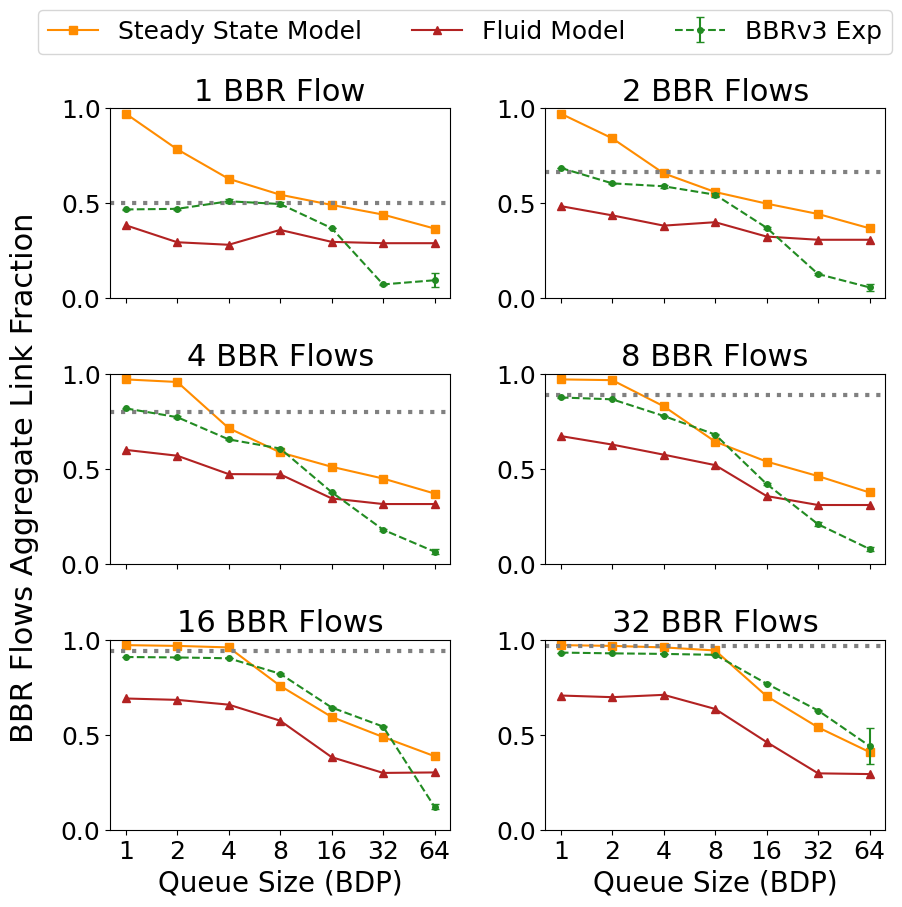

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from ware_model import * # this is for steady-state model for BBRv1 from Ware paper.
import json

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 24
})


# these are different csv files from different trials. We get the statistics over 3 trials.


data1 = read_data('bbr3-figure8a-1.csv')
data2 = read_data('bbr3-figure8a-2.csv')
data3 = read_data('bbr3-figure8a-3.csv')

# Compute the average and gather all trial data for error bars
average_data = {}
trial_data = {}
keys = data1.keys()  # Assuming the same keys in both dictionaries
for key in keys:
    values = [data1[key]/10, data2[key]/10, data3[key]/10] # 10 is the bottleneck capacity in the experiments here, you can change this.
    average_data[key] = np.mean(values)
    trial_data[key] = values


fig, axs = plt.subplots(3, 2, figsize=(10, 10))

overall_mse_model = []
overall_mse_fluid = []

for i, (ax, NBBR) in enumerate(zip(axs.flat, exp_factors['bbr_flow_number']), 1):
    dict_model = ware_BBR_Model(40, 10, np.array([1,2,4,8,16,32,64]), NBBR, 400) # this is for steady-state model for BBRv1 from Ware paper.
    BBR_frac_model = dict_model['BBR_fraction']

    filename = f'/home/fabric/work/BBR-Replication-NewExps/2022-model-2019-figure8-bbr2/{NBBR}BBR2-CUBIC-fig8a.json' # this is for fluid model.
    #filename = f'/home/fabric/work/BBR-Replication/2022-model-2019-figure8/{NBBR}BBR-CUBIC-fig8a.json'

    
    # Load the data from the file
    with open(filename, 'r') as file:
        data = json.load(file)

    # Organize data by switch buffer size
    throughputs_data = {}
    for entry in data:
        buffer_size = entry['switch_buffer']
        if buffer_size not in throughputs_data:
            throughputs_data[buffer_size] = {'BBR2': [], 'CUBIC': []} # you may need to change BBR2 or CUBIC here according to your case for the fluid model
        throughputs_data[buffer_size]['BBR2'].extend(entry['bbr2_throughputs'])
        throughputs_data[buffer_size]['CUBIC'].extend(entry['cubic_throughputs'])
    
    # Plot model data
    ax.plot([1,2,4,8,16,32,64], BBR_frac_model, 's-', color='darkorange', label='Steady State Model')

    # Prepare to plot experimental data
    exp_data = []
    exp_error_data = []

    for key, value in average_data.items():
        parts = key.split('_')
        if int(parts[3]) == NBBR:  # Matching the BBR flow number
            if parts[0] == "bbr3": # you may need to change this according to the experiments. This is for bbrv3 experiments, so we have bbr3.
                queue_size = int(parts[1])
                exp_data.append((queue_size, value))
                sem = np.std(trial_data[key], ddof=1) / np.sqrt(len(trial_data[key]))
                exp_error_data.append((queue_size, sem))

    exp_data.sort()
    exp_queue_sizes, exp_values = zip(*exp_data) if exp_data else ([], [])
    exp_errors = [e for _, e in exp_error_data]

    # Plot experimental data with error bars
    ax.errorbar(exp_queue_sizes, exp_values, yerr=exp_errors, fmt='o', color='forestgreen', ecolor='forestgreen', capsize=3, linestyle='dashed', label='BBRv3 Exp', markersize=4)

    bbr2_vals = [np.sum(throughputs_data[q_size]['BBR2'])/10 for q_size in exp_queue_sizes if q_size in throughputs_data] # 10 is for bottleneck capacity.
    ax.plot(exp_queue_sizes, bbr2_vals, '^-', color='firebrick', label='Fluid Model')

    
    # Add horizontal dotted line indicating fair sharing
    fair_share = NBBR / (NBBR + 1)  # Including one CUBIC flow
    ax.axhline(fair_share, color='gray', linestyle='dotted', linewidth=3)
    
    # Subplot formatting
    ax.set_title(f"{NBBR} BBR Flow{'s' if NBBR > 1 else ''}")
    #if i % 2 == 1:  # First column
    #    ax.set_ylabel('BBR Flows Aggregate Link Fraction')
    #else:
    #    ax.set_yticklabels([])  # Remove y-tick labels for second column

     # Subplot formatting
    ax.set_title(f"{NBBR} BBR Flow{'s' if NBBR > 1 else ''}")
    ax.set_xscale('log', base=2)
    if i > 4:  # Last row
        ax.set_xlabel('Queue Size (BDP)')
        ax.set_xticks([1,2,4,8,16,32,64])
        ax.set_xticklabels([str(x) for x in [1,2,4,8,16,32,64]])
    else:
        ax.set_xticks([1,2,4,8,16,32,64])
        ax.set_xticklabels([])  # Remove x-tick labels for first two rows
    #if i % 2 == 1:  # First column
    #    ax.set_ylabel('BBR Flows Aggregate Link Fraction')
    #else:
    #    ax.set_yticklabels([])  # Remove y-tick labels for second column
    ax.set_ylim(0, 1)

# Add a single legend at the top center of the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 0.98), ncol=4)

# Add a single large ylabel
fig.text(0.095, 0.5, 'BBR Flows Aggregate Link Fraction', va='center', rotation='vertical', fontsize=22)

# Adjust overall layout
fig.tight_layout(rect=[0.1, 0.05, 1, 0.93])

# Save plots to PDF
#plt.savefig("/home/fabric/work/BBR-Replication-NewExps/figure8a_bbrv3.pdf", format='pdf', bbox_inches='tight')

plt.show()

### Delete your slice

When you finish your experiment, you should delete your slice! The following cells deletes all the resources in your slice, freeing them for other experimenters.

In [ ]:
slice = fablib.get_slice(name=slice_name)
fablib.delete_slice(slice_name)

In [ ]:
# slice should end up in "Dead" state
# re-run this cell until you see it in "Dead" state
slice.update()
_ = slice.show()